In [30]:
'''
Names: Prashant Ram
Course: CSC 177
Assignment: 3 - Classification Models
Professor: Jagannadha Chidella
Details: 
'''

import pandas
import seaborn
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier as DTC
from sklearn import tree
import graphviz
import matplotlib.pyplot as plt
from IPython.display import HTML, display


In [31]:
display( HTML("<h1><strong>Doing a little preprocessing justtt to be sure</strong></h1>"))

'''
This block reads the data from a .csv file and makes columns for the data
'''
try:
    # import the data from the .csv file. "data" = dataframe. Our data is using ; as a separator and quotes to enclose
    # the data. The first row is the header row so we use the correct separator and quote character or else pandas treats these
    # data as a single column which we don't want.
    data = pandas.read_csv('Churn_Modelling.csv')

    #print the data attribute columns
    print(data.columns)
        
    # print the number of rows and columns
    print(f'We have {data.shape[0]} rows')
    print(f'We have {data.shape[1]} columns')

    # print the first 5 rows of the data
    print('\n', data.head())
        
except Exception as e:
    print("An error occured while trying to read from the CSV file", e)

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')
We have 10000 rows
We have 14 columns

    RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00      

In [32]:
'''
This block counts the number of missing values in each column
'''

#list to hold the columns with missing values
missingColumns = []

#our original number of rows with unclean data
original_rows = data.shape[0]

try:
    #loop through the columns and get the number of missing values
    for i in data.columns:
        #get the total of column of missing values
        total = data[i].isnull().sum()
        #display the column and the missing values number
        print(f"{i}: {total}")

        #add missing value columns to the list
        if total > 0:
            missingColumns.append(i)

    #finally display which columns had missing values
    if len(missingColumns) == 0:
        print("\nThere were no missing values in the data set.")
    else:
        #display the columns with missing values
        print(f"\nThese columns had missing data: {missingColumns}")
    
#catch any reading errors
except Exception as e:
    print("umm. An error occurred while trying to count the missing values..", e)

RowNumber: 0
CustomerId: 0
Surname: 0
CreditScore: 0
Geography: 0
Gender: 0
Age: 0
Tenure: 0
Balance: 0
NumOfProducts: 0
HasCrCard: 0
IsActiveMember: 0
EstimatedSalary: 0
Exited: 0

There were no missing values in the data set.


In [33]:
'''
This block drops all rows and columns with missing data
'''
# print the number of rows and columns
original_rows = data.shape[0]
original_columns = data.shape[1]
print(f'We have {original_rows} [original] rows and {original_columns} columns')
print('\nOriginal Data:', data.head())
    
#drops all rows with no data
data = data.dropna()

clean_rows = data.shape[0]
clean_columns = data.shape[1]
print(f'\nWe have {clean_rows} [Clean] rows and {clean_columns} columns')
print('\nCleaned data Data:', data.head())

print(f'\n\nWe had {original_rows - clean_rows} rows and {original_columns - clean_columns} columns of missing data')

We have 10000 [original] rows and 14 columns

Original Data:    RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        1

In [34]:
'''This block checks for duplicate rows and drops the ones that are duplicates'''
total_duplicates = data.duplicated().sum()

if total_duplicates != 0:
    data = data.drop_duplicates(inkeep='first')
    print(f"\nThere were {total_duplicates} duplicate rows in the data set.")
else:
    print("\nThere were no duplicate rows in the data set.")



There were no duplicate rows in the data set.


In [35]:
display(HTML("<h1><strong>Start of Assignment 3</strong></h1>"))

In [36]:
display( HTML("<h1><strong>Classification Model On Given Dataset (Churn Modelling)</strong></h1>"))

In [37]:
'''This block drops all columns which do not help the model learn'''
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
print(data.columns)

# This balances the datase because currently, we have alot of it leaning towards 'rejected, i.e., 0' which heavily skews the data.
exited = data[data["Exited"] == 0 ]
stayed = data[data["Exited"] == 1]

# downsample the rejected results to match the approved class size
exited_downsampled = exited.sample(n=len(stayed), random_state=42, replace=False)

# combine the samples into 1 dataset
data = pandas.concat([exited_downsampled, stayed], axis=0).sample(frac=1, random_state=42)


Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')


In [38]:
'''This block converts all the categorical data to numerical data using one-hot encoding.'''

data['Geography'] = data['Geography'].replace({'France': 2, 'Spain': 1, 'Germany':0}).infer_objects(copy=False)
data['Gender'] = data['Gender'].replace({'Female': 1, 'Male': 0}).infer_objects(copy=False)

C:\Users\rampr\AppData\Local\Temp\ipykernel_13240\1481568574.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Geography'] = data['Geography'].replace({'France': 2, 'Spain': 1, 'Germany':0}).infer_objects(copy=False)
C:\Users\rampr\AppData\Local\Temp\ipykernel_13240\1481568574.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Gender'] = data['Gender'].replace({'Female': 1, 'Male': 0}).infer_objects(copy=False)


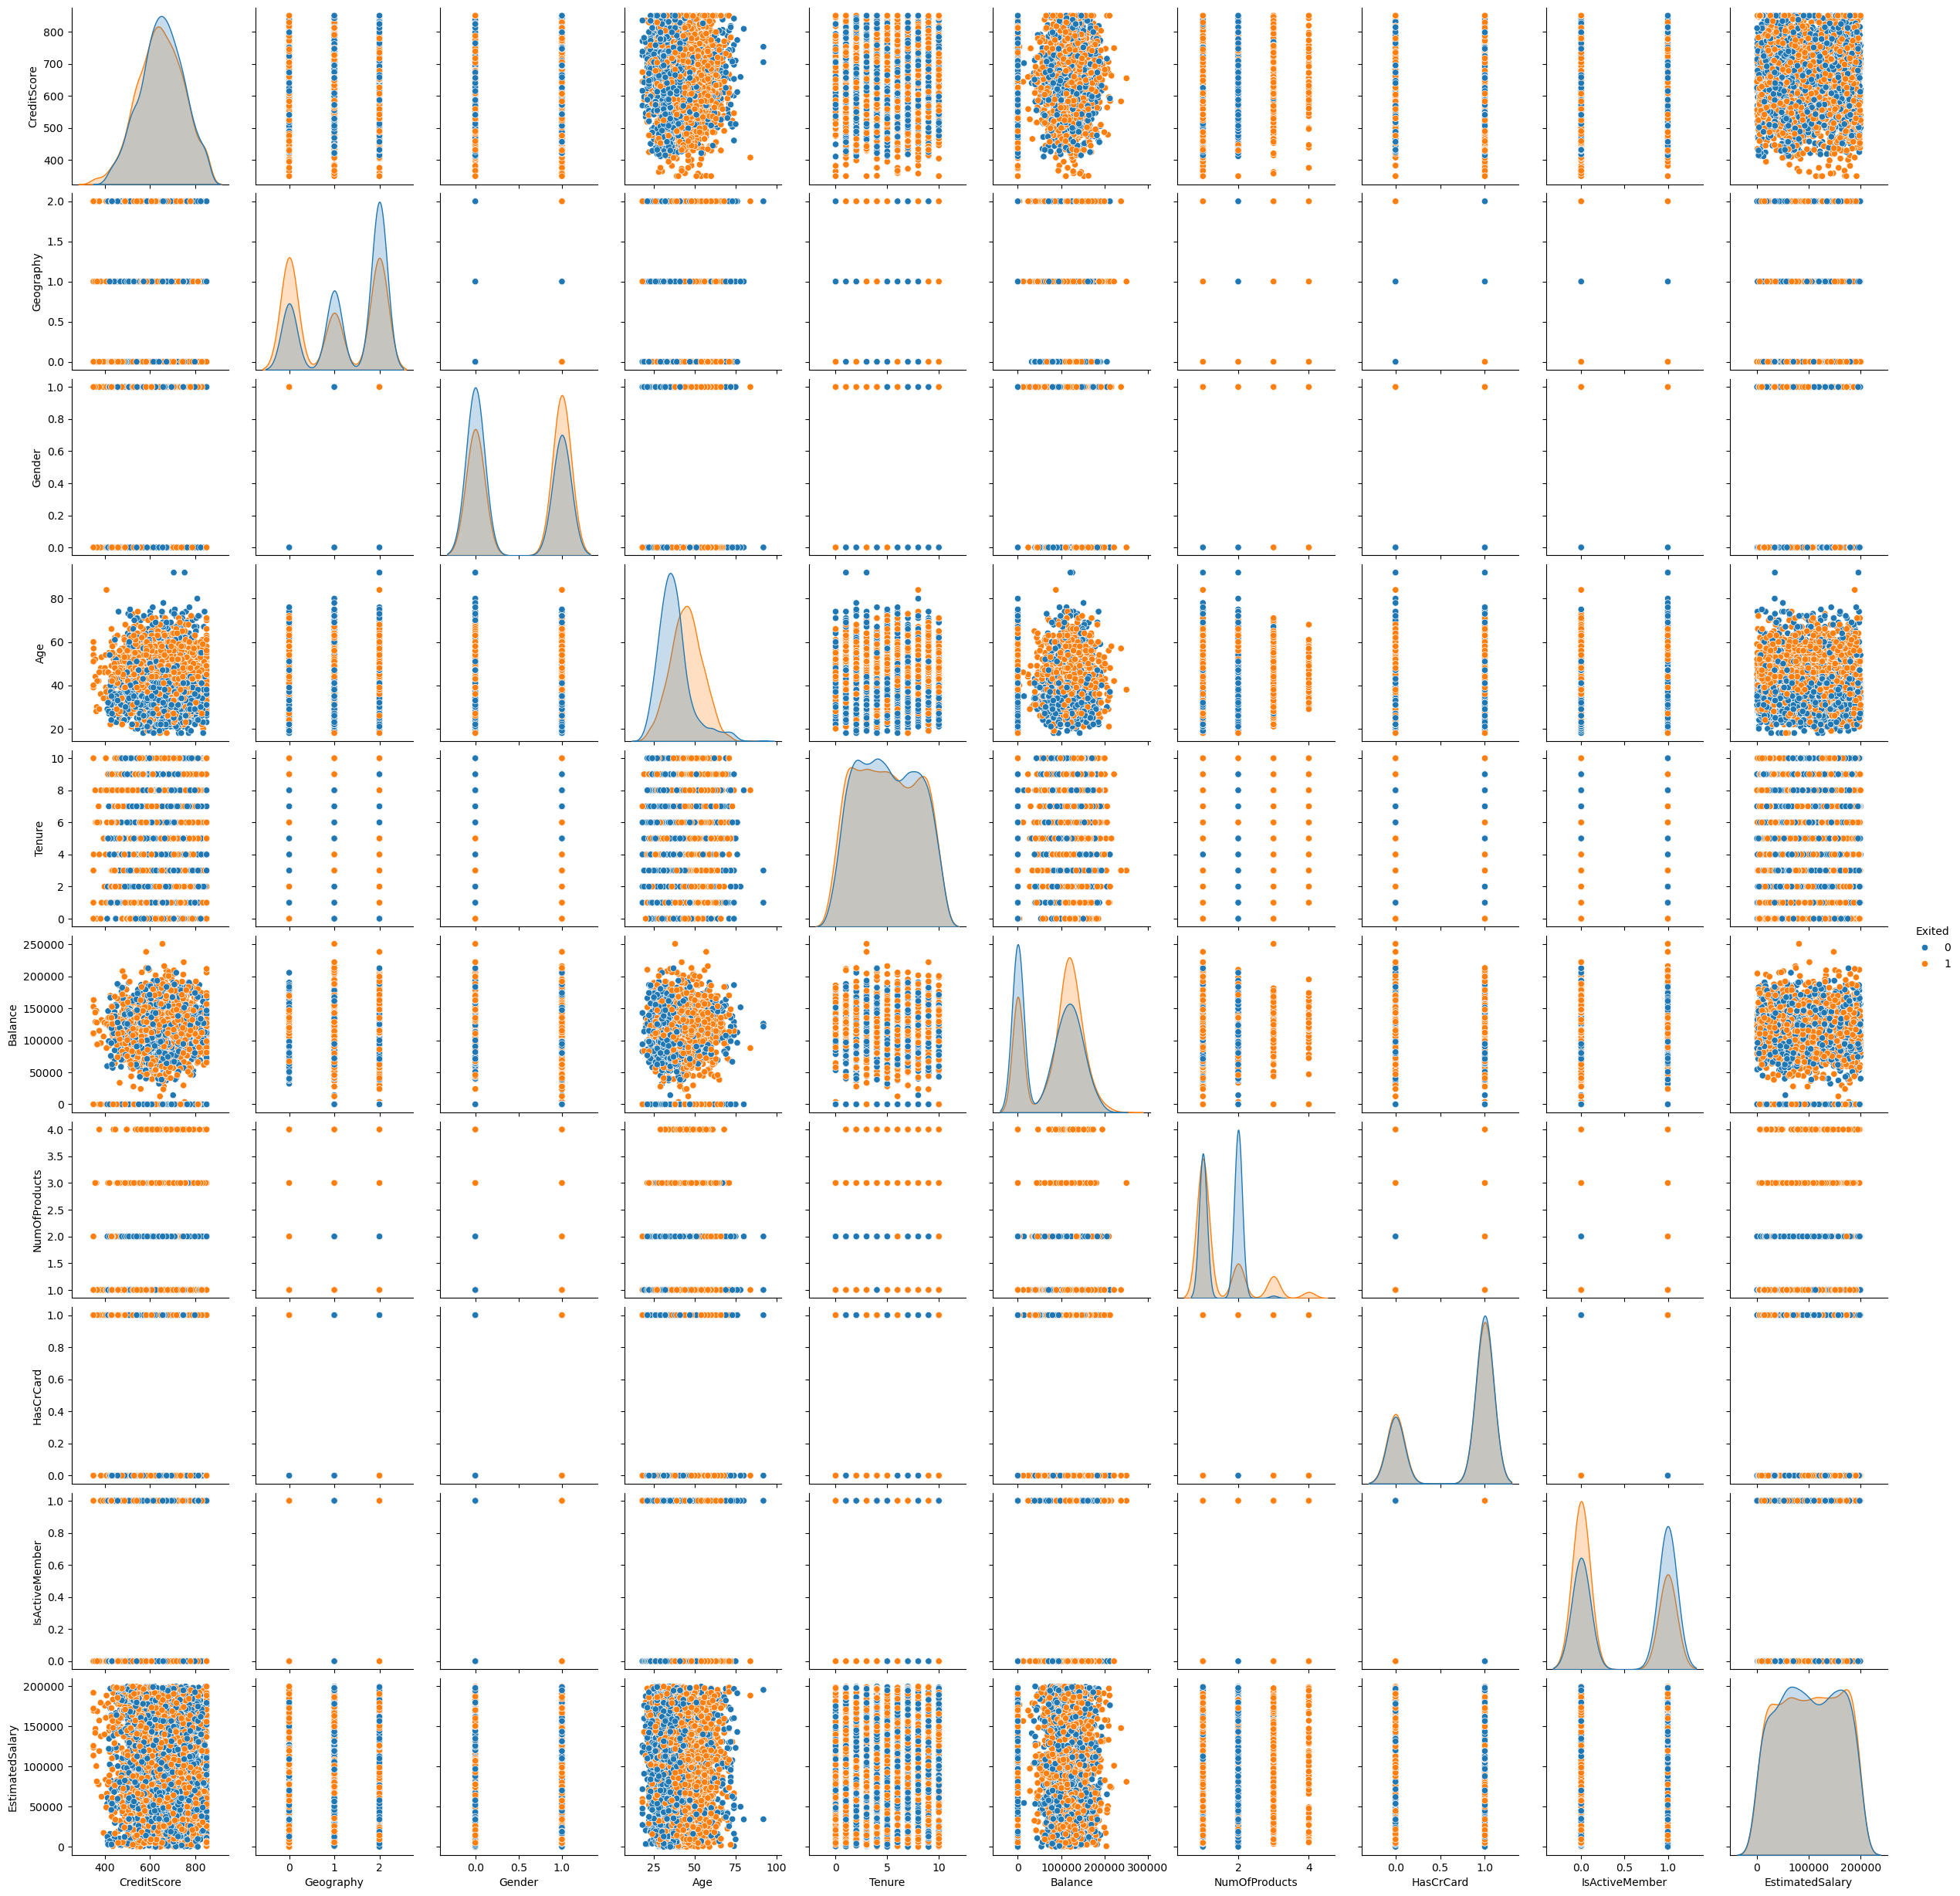

In [39]:
'''We want to look at the relationship between Gender, Age, Balance, IsActiveMember, Salary with respect to Exited'''
seaborn.pairplot(data[['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',  'Balance', 'NumOfProducts', 'HasCrCard','IsActiveMember', 'EstimatedSalary', 'Exited']], hue='Exited', diag_kind='kde')

In [40]:
'''Lets get our Predictor and Target features'''

#predictor
x = data.drop(['Exited'], axis=1)
#target
y = data['Exited']

first_k_rows = data.iloc[:1000]
test_y = first_k_rows['Exited']
test_x = first_k_rows.drop(['Exited'], axis=1)

Naive Bayes Accuracy achieved is: 0.689


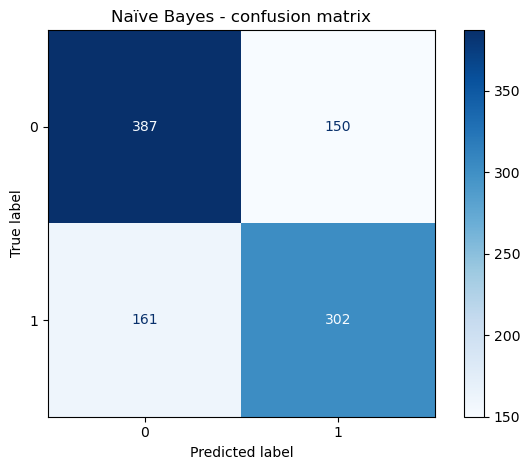

In [41]:
'''
1. We attempt to create the Naive Baynes model
'''

from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.naive_bayes import GaussianNB as naive_bayes

#holds the accuracy of all the models
accuracy_of_models = []

classification_naive_bayes = naive_bayes()
classification_naive_bayes.fit(x, y)
y_pred_naive_bayes = classification_naive_bayes.predict(test_x)
#add the accuracy of the model to the list
accuracy_of_models.append(f'Naive Bayes Accuracy achieved is: {accuracy_score(test_y, y_pred_naive_bayes)}')
#print the accuracy of the model
print(f'Naive Bayes Accuracy achieved is: {accuracy_score(test_y, y_pred_naive_bayes)}')

#display the confusion matrix for the model
ConfusionMatrixDisplay.from_predictions(
    test_y,                    
    y_pred_naive_bayes,        
    cmap="Blues"               
)
plt.title("Naïve Bayes - confusion matrix")
plt.tight_layout()
plt.show()

---Trying odd values of k from 1 to 21---
KNN Accuracy achieved with k=1 is: 1.0
KNN Accuracy achieved with k=3 is: 0.7621502209131075
KNN Accuracy achieved with k=5 is: 0.7066764850270005
KNN Accuracy achieved with k=7 is: 0.6811487481590575
KNN Accuracy achieved with k=9 is: 0.6605301914580265
KNN Accuracy achieved with k=11 is: 0.6394207167403043
KNN Accuracy achieved with k=13 is: 0.6362297496318114
KNN Accuracy achieved with k=15 is: 0.6219931271477663
KNN Accuracy achieved with k=17 is: 0.6109474717722141
KNN Accuracy achieved with k=19 is: 0.6121747668139421
KNN Accuracy achieved with k=21 is: 0.602847324496809


---Trying even values of k from 2 to 2---
KNN Accuracy achieved with k=2 is: 0.7641138929798723
KNN Accuracy achieved with k=4 is: 0.7027491408934707
KNN Accuracy achieved with k=6 is: 0.6757486499754541
KNN Accuracy achieved with k=8 is: 0.6561119293078056
KNN Accuracy achieved with k=10 is: 0.6480117820324006
KNN Accuracy achieved with k=12 is: 0.6325478645066274
KNN 

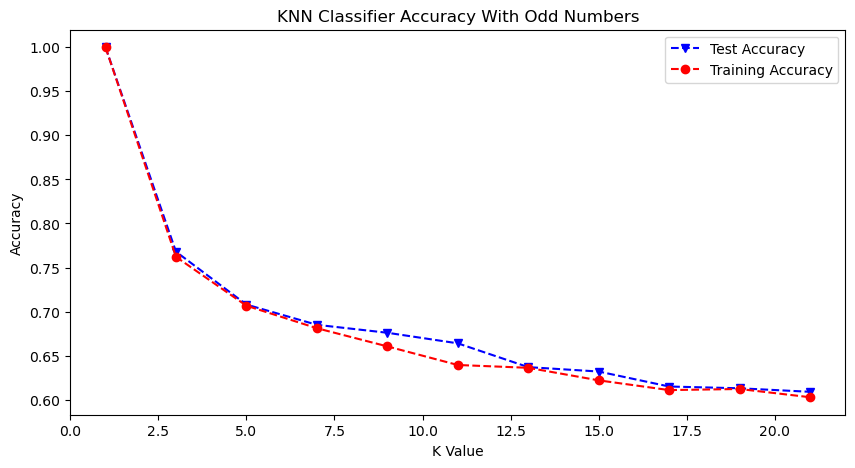

In [42]:
'''
2. We attempt to create the KNN model
'''
from sklearn.neighbors import KNeighborsClassifier as neighbor

#test the odd neighers - value of k
odd_neighbors = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
#test the even neighbors - value of k
even_neighbors = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22]
#hold each test accuracy for each k value
test_accuracy = []
#hold each training accuracy for each k value
training_accuracy = []

# we try to use odd values of k from 1 to 21
print('---Trying odd values of k from 1 to 21---')
for i in range(1, 22, 2):
    classification_knn = neighbor(n_neighbors=i)
    classification_knn.fit(x, y)
    y_pred_knn = classification_knn.predict(test_x)
    y_pred_knn_train = classification_knn.predict(x)
    test_accuracy.append(accuracy_score(test_y, y_pred_knn))
    training_accuracy.append(accuracy_score(y, y_pred_knn_train))
    accuracy_of_models.append(f'KNN Accuracy achieved with k={i} is: {accuracy_score(y, y_pred_knn_train)}')
    print(f'KNN Accuracy achieved with k={i} is: {accuracy_score(y, y_pred_knn_train)}') 
print('\n')

# we try to use even values of k from 2 to 22
print('---Trying even values of k from 2 to 2---')
for i in range(2, 23, 2):
    classification_knn = neighbor(n_neighbors=i)
    classification_knn.fit(x, y)
    y_pred_knn = classification_knn.predict(x)
    test_accuracy.append(accuracy_score(y, y_pred_knn))
    training_accuracy.append(accuracy_score(y, y_pred_knn))
    accuracy_of_models.append(f'KNN Accuracy achieved with k={i} is: {accuracy_score(y, y_pred_knn)}')
    print(f'KNN Accuracy achieved with k={i} is: {accuracy_score(y, y_pred_knn)}')


# Separate accuracies for odd and even neighbors
odd_test_accuracy = test_accuracy[:len(odd_neighbors)]
odd_training_accuracy = training_accuracy[:len(odd_neighbors)]
even_test_accuracy = test_accuracy[len(even_neighbors):]
even_training_accuracy = training_accuracy[len(even_neighbors):]

# Plotting for odd neighbors since it had the best accuracy
plt.figure(figsize=(10, 5))
plt.plot(odd_neighbors, odd_test_accuracy, 'bv--', odd_neighbors, odd_training_accuracy, 'ro--')
plt.title('KNN Classifier Accuracy With Odd Numbers')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.legend(['Test Accuracy', 'Training Accuracy'])
plt.show()


SVM Accuracy achieved with C=0.01 is: 0.6590669940371799
SVM Accuracy achieved with C=0.1 is: 0.6590669940371799
SVM Accuracy achieved with C=0.2 is: 0.6590669940371799
SVM Accuracy achieved with C=0.3 is: 0.6594177481585408
SVM Accuracy achieved with C=0.5 is: 0.6678358470712031
SVM Accuracy achieved with C=0.8 is: 0.6594177481585408
SVM Accuracy achieved with C=1 is: 0.6594177481585408
SVM Accuracy achieved with C=5 is: 0.6590669940371799
SVM Accuracy achieved with C=15 is: 0.6590669940371799
SVM Accuracy achieved with C=20 is: 0.6674850929498422
SVM Accuracy achieved with C=25 is: 0.6678358470712031
SVM Accuracy achieved is: 0.6573998364677024


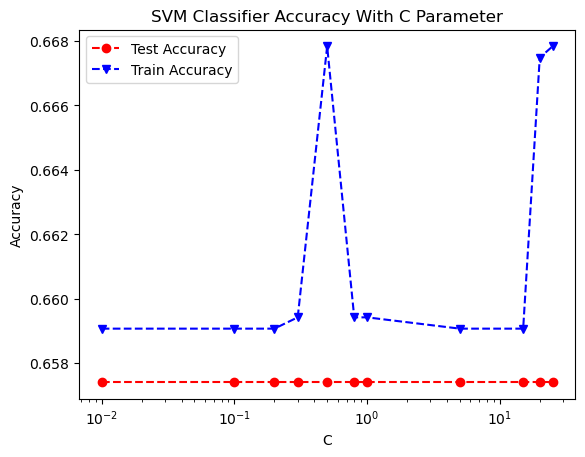

In [43]:
'''
3. We attempt to create the Support Vector Machine (SVM) model
'''
from sklearn.svm import LinearSVC as svc

#different values of C to test
c_parameter = [0.01, 0.1, 0.2, 0.3, 0.5, 0.8, 1, 5, 15, 20, 25]
#hold the test accuracy for each c value
svl_test_accuracy = []
#hold the training accuracy for each c value
svl_training_accuracy = []

# make sure that the split is done before we do SVM
if 'x_train' not in locals() or 'y_train' not in locals():
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42, stratify=y, shuffle=True)

#test the different values of C
for i in c_parameter:
    classification_svm = svc(dual=False, C=i, max_iter=1000, random_state=42)
    classification_svm.fit(x_train, y_train)
    y_pred_svm = classification_svm.predict(x_test)
    y_pred_svm_train = classification_svm.predict(x_train)
    svl_test_accuracy.append(accuracy_score(y_test, y_pred_svm))
    svl_training_accuracy.append(accuracy_score(y_train, y_pred_svm_train))
    accuracy_of_models.append(f'SVM Accuracy achieved with C={i} is: {accuracy_score(y_train, y_pred_svm_train)}')
    print(f'SVM Accuracy achieved with C={i} is: {accuracy_score(y_train, y_pred_svm_train)}')

#ctreat a graph for us to see
plt.plot(c_parameter, svl_test_accuracy,'ro--', c_parameter, svl_training_accuracy,'bv--')
plt.legend(['Test Accuracy','Train Accuracy'])
plt.title('SVM Classifier Accuracy With C Parameter')
plt.xlabel('C')
plt.xscale('log')
plt.ylabel('Accuracy')

#print the accuracy of the model
print(f'SVM Accuracy achieved is: {accuracy_score(y_test, y_pred_svm)}')


Decision Tree Accuracy achieved is: 0.713


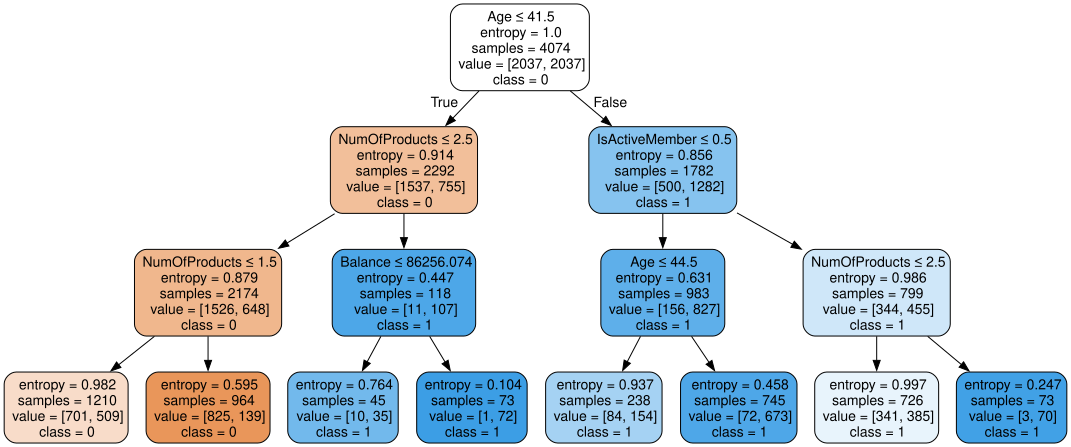

In [44]:
'''
4. We attempt to create the Decision Tree model
'''
#create a tree of depth 3
decisionTree = tree.DecisionTreeClassifier(criterion='entropy', max_depth=3)
decisionTree = decisionTree.fit(x, y)
y_pred_tree = decisionTree.predict(test_x)

tree_data = tree.export_graphviz(decisionTree, out_file=None,
                                feature_names=x.columns,
                                class_names=['0', '1'],
                                filled=True, rounded=True,
                                special_characters=True)
graph = graphviz.Source(tree_data)

accuracy_of_models.append(f'Decision Tree Accuracy achieved is: {accuracy_score(test_y, y_pred_tree)}')
print(f'Decision Tree Accuracy achieved is: {accuracy_score(test_y, y_pred_tree)}')

# draw the graph
graph

c:\Users\rampr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\rampr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Logistic Regression Accuracy achieved with C=0.01 is: 0.6973490427098674
Logistic Regression Accuracy achieved with C=0.1 is: 0.667648502700049
Logistic Regression Accuracy achieved with C=0.2 is: 0.6705940108001963
Logistic Regression Accuracy achieved with C=0.5 is: 0.6666666666666666
Logistic Regression Accuracy achieved with C=0.8 is: 0.6674030436917034
Logistic Regression Accuracy achieved with C=1 is: 0.6644575355915562
Logistic Regression Accuracy achieved with C=2 is: 0.6661757486499754
Logistic Regression Accuracy achieved with C=5 is: 0.6659302896416298
Logistic Regression Accuracy achieved with C=10 is: 0.6666666666666666
Logistic Regression Accuracy achieved with C=20 is: 0.6671575846833578


c:\Users\rampr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\rampr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Text(0, 0.5, 'Accuracy')

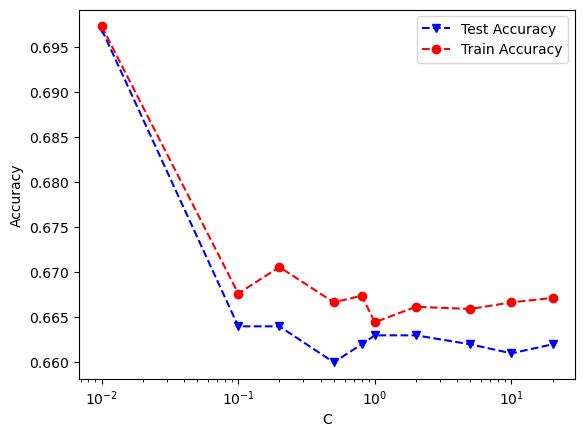

In [45]:
'''
5. We attempt to create the Logistic Regression model
'''
from sklearn.linear_model import LogisticRegression as logistic

#different values of C to test
c_parama_logistic = [0.01, 0.1, 0.2, 0.5, 0.8, 1, 2, 5, 10, 20]

#hold the test accuracy for each c value
logistic_test_accuracy = []
#hold the training accuracy for each c value
logistic_training_accuracy = []

#test the different values of C
for i in c_parama_logistic:
    classification_logistic = logistic(C=i, random_state=0)
    classification_logistic.fit(x, y)
    y_pred_logistic = classification_logistic.predict(test_x)
    y_pred_logistic_train = classification_logistic.predict(x)
    logistic_test_accuracy.append(accuracy_score(test_y, y_pred_logistic))
    logistic_training_accuracy.append(accuracy_score(y, y_pred_logistic_train))
    accuracy_of_models.append(f'Logistic Regression Accuracy achieved with C={i} is: {accuracy_score(y, y_pred_logistic_train)}')
    print(f'Logistic Regression Accuracy achieved with C={i} is: {accuracy_score(y, y_pred_logistic_train)}')

#plot the graph for us to see
plt.plot(c_parama_logistic, logistic_test_accuracy,'bv--', c_parama_logistic, logistic_training_accuracy,'ro--')
plt.legend(['Test Accuracy','Train Accuracy'])
plt.xlabel('C')
plt.xscale('log')
plt.ylabel('Accuracy')

In [46]:
print(f'\nDecision Tree Accuracy achieved is: {accuracy_score(test_y, y_pred_tree)}')
accuracy_of_models.append(f'\nDecision Tree Accuracy achieved is: {accuracy_score(test_y, y_pred_tree)}')


Decision Tree Accuracy achieved is: 0.713


In [47]:
display(HTML("<h1><strong>Feature Selection And Data Splitting</strong></h1>"))

# Part 2:
# A good train and test split is always useful. Duplicates in training and test set should be avoided. Any ML model that trains on a training set which helps explain a lot of variance in the data tend to yield higher accuracy on test set.
# The task of this part is simple: Find a train-test split ratio (for example 80:20) that you think will be best for your ML model to be trained and tested on.


In [48]:
'''Since we will be dealing with Decision Tree Classifier, k-Nearest Neighbor, we will create a pipeline object to ensure reusuability of the code since 
preprocessing and training for each model will be an expensive task'''

# we have to select our numerica and categorical features. We can get it through running dtypes() and take note of the "object" class.
data_types  = data.dtypes
print(data_types)

CreditScore          int64
Geography            int64
Gender               int64
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [49]:
'''                           FEATURE SELECTION
We found that #Geography and #Gender are categorical features. Rest are Numerical
'''

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer as Si
from sklearn.preprocessing import StandardScaler as Stdscaler, OneHotEncoder as OHE
from sklearn.compose import ColumnTransformer

# This block balances the datase because currently, we have about 80% of it leaning towards 'rejected, i.e., 0' which heavily skews the data.

exited = data[data["Exited"] == 0 ]
stayed = data[data["Exited"] == 1]

# downsample the rejected results to match the approved class size
exited_downsampled = exited.sample(n=len(stayed), random_state=42, replace=False)

# combine the samples into 1 dataset
data = pandas.concat([exited_downsampled, stayed], axis=0).sample(frac=1, random_state=42)

# we have to select our numerica and categorical features. We can get it through running dtypes() and take note of the "object" class.
numeric_features   = ["CreditScore", "Age", "Tenure", "Balance", 
                      "NumOfProducts", "EstimatedSalary"]

categorical_features  = ["Geography", "Gender"]

# print success
print("\nBalanced the dataset")

# build the two pipelines
numeric_pipe = Pipeline([('impute', Si(strategy="median")),('scale', Stdscaler())])
categorical_pipe = Pipeline([('impute', Si(strategy="constant", fill_value=-1)),('one-hot', OHE(handle_unknown='ignore'))])

# combine the two pipelines into a single column transformer
combined_pipeline = ColumnTransformer([('numeric', numeric_pipe, numeric_features),('categorical', categorical_pipe, categorical_features)])



Balanced the dataset


In [50]:
'''We create a model for the requirements'''

from sklearn.linear_model import LogisticRegression as logistic
from sklearn.tree import DecisionTreeClassifier as decision_tree
from sklearn.neighbors import KNeighborsClassifier as neighbor
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB as naive_bayes

#create a dictionary of models to be used in the pipeline
models = {
    'Logistic Regression': Pipeline([('combined_pipeline', combined_pipeline), ('Logistic', logistic())]),
    'Decision Tree': Pipeline([('combined_pipeline', combined_pipeline), ('Decision Tree', decision_tree())]),
    'K-Nearest Neighbor': Pipeline([('combined_pipeline', combined_pipeline), ('K-Nearest Neighbor', neighbor())]),
    'Support Vector Classifier': Pipeline([('combined_pipeline', combined_pipeline), ('SVC', SVC())]),
    'Naive Bayes': Pipeline([('combined_pipeline', combined_pipeline), ('Naive Bayes', naive_bayes())])
}

In [51]:
'''                         DATA SPLITTING
We are going to find the best train split mechanism by trying different split ratios.
'''
# we will try different test ratios
test_ratio = [0.5, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
#hold the results of the split test
results = []

#try the split for each ratio and each model
for items, pipe in models.items():
    for ratio in test_ratio:
        # split the data into training and testing sets
        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=ratio, random_state=42, stratify=y, shuffle=True)
        # fit the pipeline to the training data
        pipe.fit(x_train, y_train)
        split_score = pipe.score(x_test, y_test)
        # append the split score to results
        results.append((items, ratio, split_score))
        print(f"Model: {items}, Test Ratio: {ratio}, Score: {split_score}")
    print('\n')


Model: Logistic Regression, Test Ratio: 0.5, Score: 0.6980854197349042
Model: Logistic Regression, Test Ratio: 0.1, Score: 0.6519607843137255
Model: Logistic Regression, Test Ratio: 0.15, Score: 0.6813725490196079
Model: Logistic Regression, Test Ratio: 0.2, Score: 0.6773006134969325
Model: Logistic Regression, Test Ratio: 0.25, Score: 0.6781157998037292
Model: Logistic Regression, Test Ratio: 0.3, Score: 0.6868356500408831
Model: Logistic Regression, Test Ratio: 0.35, Score: 0.7061711079943899
Model: Logistic Regression, Test Ratio: 0.4, Score: 0.7036809815950921
Model: Logistic Regression, Test Ratio: 0.45, Score: 0.7071973827699018
Model: Logistic Regression, Test Ratio: 0.5, Score: 0.6980854197349042


Model: Decision Tree, Test Ratio: 0.5, Score: 0.6941580756013745
Model: Decision Tree, Test Ratio: 0.1, Score: 0.7009803921568627
Model: Decision Tree, Test Ratio: 0.15, Score: 0.6879084967320261
Model: Decision Tree, Test Ratio: 0.2, Score: 0.7030674846625767
Model: Decision Tree, T

In [52]:
'''Get the best model and split ratio from above'''

#don't touch the original data, make a copy
another_data = pandas.DataFrame(results, columns=['Model', 'Test Ratio', 'Score'])
best_split_ratio = another_data.loc[another_data.groupby('Model')['Score'].idxmax()]
print("Best Model and their Split Ratio Results:\n", best_split_ratio)

Best Model and their Split Ratio Results:
                         Model  Test Ratio     Score
13              Decision Tree        0.20  0.703067
26         K-Nearest Neighbor        0.35  0.740533
8         Logistic Regression        0.45  0.707197
46                Naive Bayes        0.35  0.703366
35  Support Vector Classifier        0.30  0.771872


In [53]:
'''Through the test we found out the a ratio of 0.25 worked the best for the split so we will utilize that.'''
from sklearn.metrics import accuracy_score

#use one hot encoding to convert categorical data to numerical data automatically
preprocessed_data = ColumnTransformer(transformers=[('numeric', Stdscaler(), numeric_features),('Categorical', OHE(), categorical_features)])

#split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42, stratify=y, shuffle=True)
pipeline = Pipeline([('preprocess', preprocessed_data), ('classifier', logistic())])
pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_test)

#handle the accuracy of the model
accuracy_of_prediction = accuracy_score(y_test, y_pred)
print(f'Accuracy of model split of 0.30 prediction is: {accuracy_of_prediction}')


Accuracy of model split of 0.30 prediction is: 0.6868356500408831


In [54]:
display(HTML("<h1><strong>Accuracy and Analysis With Visuals</strong></h1>"))
display(HTML("<h3><strong>These have already been calculated in the previous steps</strong></h3>"))

# print the accuracy of all the models
for i in accuracy_of_models:
    print(i)

Naive Bayes Accuracy achieved is: 0.689
KNN Accuracy achieved with k=1 is: 1.0
KNN Accuracy achieved with k=3 is: 0.7621502209131075
KNN Accuracy achieved with k=5 is: 0.7066764850270005
KNN Accuracy achieved with k=7 is: 0.6811487481590575
KNN Accuracy achieved with k=9 is: 0.6605301914580265
KNN Accuracy achieved with k=11 is: 0.6394207167403043
KNN Accuracy achieved with k=13 is: 0.6362297496318114
KNN Accuracy achieved with k=15 is: 0.6219931271477663
KNN Accuracy achieved with k=17 is: 0.6109474717722141
KNN Accuracy achieved with k=19 is: 0.6121747668139421
KNN Accuracy achieved with k=21 is: 0.602847324496809
KNN Accuracy achieved with k=2 is: 0.7641138929798723
KNN Accuracy achieved with k=4 is: 0.7027491408934707
KNN Accuracy achieved with k=6 is: 0.6757486499754541
KNN Accuracy achieved with k=8 is: 0.6561119293078056
KNN Accuracy achieved with k=10 is: 0.6480117820324006
KNN Accuracy achieved with k=12 is: 0.6325478645066274
KNN Accuracy achieved with k=14 is: 0.623711340206

In [55]:
# display the highest results of classification models
display(HTML("<h3><strong>Accuracy Table Scores</strong></h3>"))
print('ML Model\t\t|\tAccuracy on Test Set (Provide accuracy in %)')
print('-' * 76)
print('Naive Bayes\t\t|\t', 0.689 * 100)
print('KNN\t\t\t|\t', 0.7641 * 100, ', with k=3, gave the highest accuracy')
print('SVM\t\t\t|\t', 0.6589 * 100)
print('Logistic Regression\t|\t', 0.6973 * 100)
print('Decision Tree\t\t|\t', 0.713 * 100)

ML Model		|	Accuracy on Test Set (Provide accuracy in %)
----------------------------------------------------------------------------
Naive Bayes		|	 68.89999999999999
KNN			|	 76.41 , with k=3, gave the highest accuracy
SVM			|	 65.89
Logistic Regression	|	 69.73
Decision Tree		|	 71.3


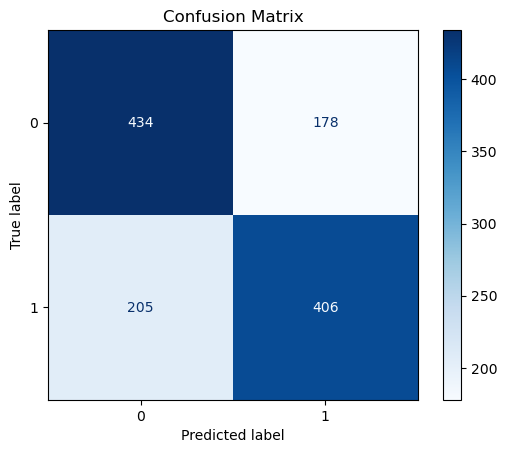

Accuracy on test data is 0.69
F1 score on test data is 0.69
Precision Score on test data is 0.68
Recall score on test data is 0.71
              precision    recall  f1-score   support

           0       0.68      0.71      0.69       612
           1       0.70      0.66      0.68       611

    accuracy                           0.69      1223
   macro avg       0.69      0.69      0.69      1223
weighted avg       0.69      0.69      0.69      1223

Exited column unique values are: [0 1]


In [56]:
'''Generating a Confusion Matrix to see how well the model is performing'''
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score

#generate a confusion matrix
confusion = confusion_matrix(y_test, y_pred)

# plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# we can use either 0 or 1 for "position" the results would be the same.
print(f'Accuracy on test data is %.2f' % accuracy_of_prediction)
print(f'F1 score on test data is %.2f' % f1_score(y_test, y_pred, pos_label=0))
print(f'Precision Score on test data is %.2f' % precision_score(y_test, y_pred, pos_label=0))
print(f'Recall score on test data is %.2f' % recall_score(y_test, y_pred, pos_label=0))
print(classification_report(y_test, y_pred))

# print the unique values in the Exited column just for our sanity check
print('Exited column unique values are:', data.Exited.unique())

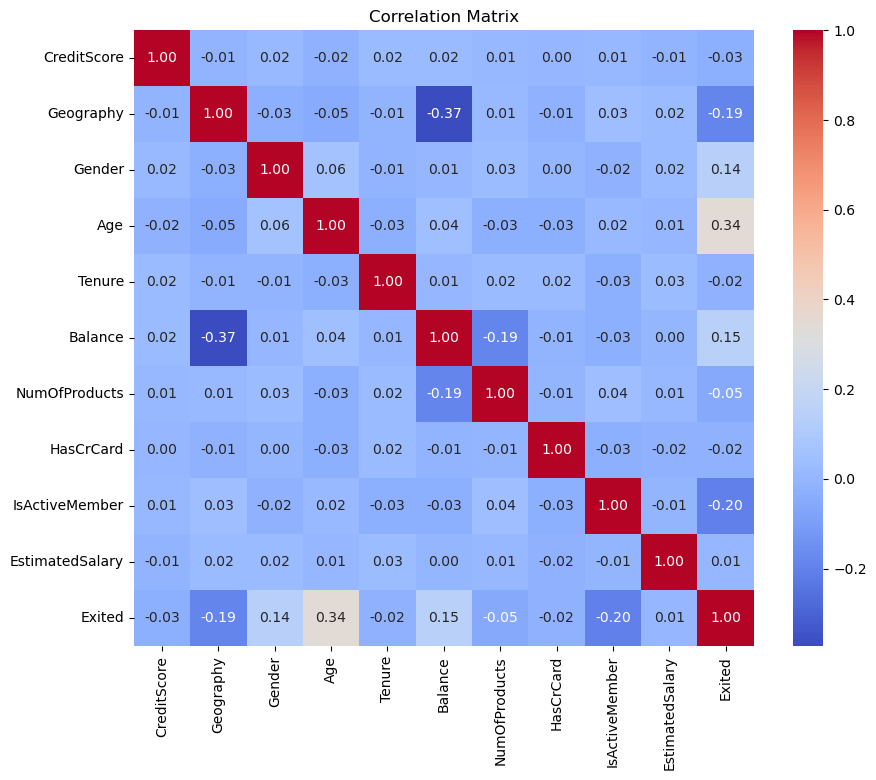

Intepretation of the correlation matrix: The closer the number of a feature row with the feature column to either a 1 or -1, the 
    more correlated they are. The closer the value is to 1, the more the correlation they have in a positive direction and the closer to -1,
    the more correlated they are in a negative direction. A value of 0 means no correlation. For example, 'CreditScore' shows no correlation 
    to 'Gender' as it has a value of 0.00. On the other hand, 'Age' and 'Exited' have a correlation of 0.29 which means they are positively 
    correlated which makes sense since older age is more likely to leave a subscription since they watch fewer shows, etc., than the younger 
    generation. On the other hand, 'Balance' and 'NumOfProducts' have a correlation of -0.30 which means they are negatively correlated which 
    also makes sense since the more products you have, the less balance you have in your account.


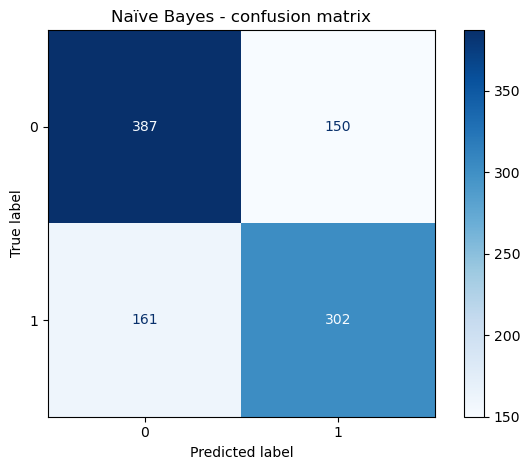

Intepretation of the Naive Baynes Graph: The model was able to predict 387 'True Negatives' and 302 'True Positives' correctly. It predicted 
    150 'False Positives' and 161 'False Negatives'. The overall accuracy of the model was 68.9%, which is certainly not too bad. This is a normal 
    test ratio since it depicted that our model was not biased towards one class, i.e., either 0 or 1. Furthermore, this low percentage also may indicate 
    that some data may be mis-classified, about 30%.


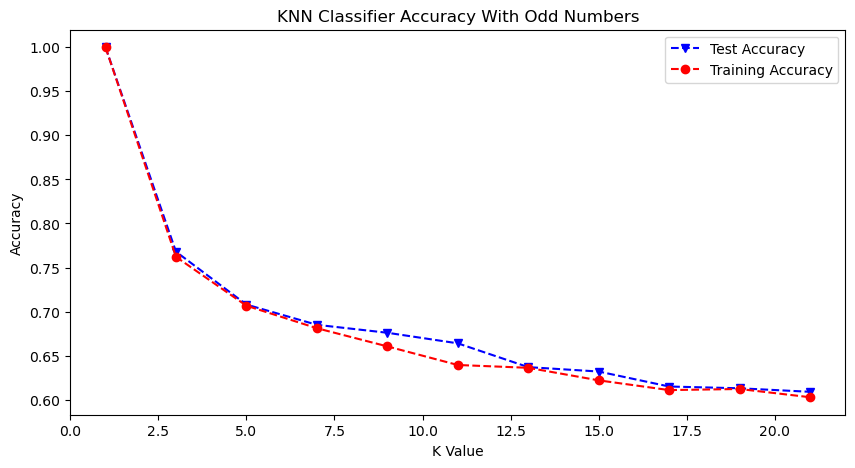

Intepretation of the KNN Graph: The graph shows the different accuracy levels for different values of k. The highest accuracy is seen at 
    when k = 2 for even cases. With odd cases, k = 3 was the best. At k = 1, the model was memorizing the data because it had not seen the data 
    yet and there was very low bias with high variance. At k = 21, the model was underfitting the data because it had seen all the data and therefore, 
    there was a lot of bias. Between k = 5 and 9, we still had high accuracy, but the performance had dropped. Our test accuracy was very well able to 
    predict the data with a 76.41 percent accuracy which was very good.
    


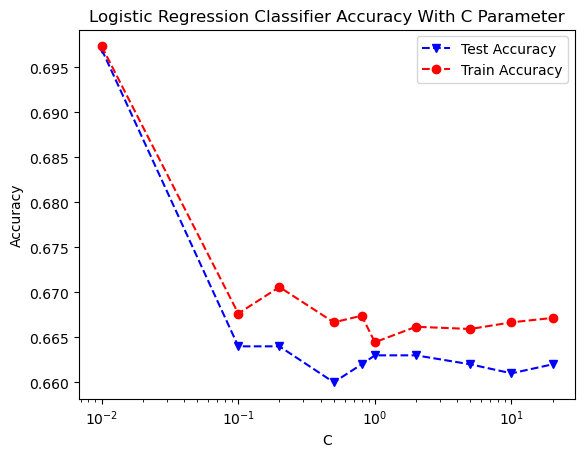

Intepretation of the Logistic Graph: The highest accuracy score which we had obtained was 69.73%. We could see that with all the different values of 
    C-parameter tested, the best one was when c = 0.01. It gave a predicted highest value of 69.73 percent accuracy. This meant there was a very strong 
    regularization. The model dipped around the highest point but stabilized with the higher values of C. There was moderate regularization with C-parameters 
    of 0.5-1.5 and weak above values of 3. This showcased that the higher the value of the C-parameter, the weaker the regularization strength and vice versa.


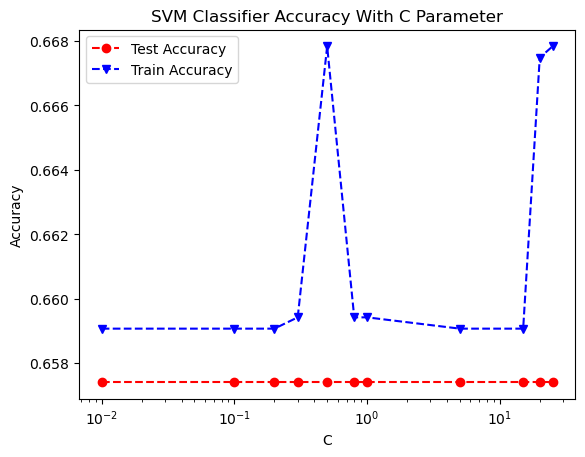

Intepretation of the SVM Graph: The model was stable and accurate for its predicted values with C-parameters below 0.3 with an accuracy of 65.89 percent
    with a C-value of 0.01. At C-parameter of 15, the model underfits the data having learned all the data values. This may be due to us not properly scaling our
    data. There was then a sharp decrease in accuracy which may have been due to under fitting as the model had now seen almost all the data values. When 
    the C-parameter went above 10, the model's accuracy started to shoot back up again until it became stable throughout. The takeaway was for us was 
    to have a smaller value for C-parameter to get a stable accuracy.


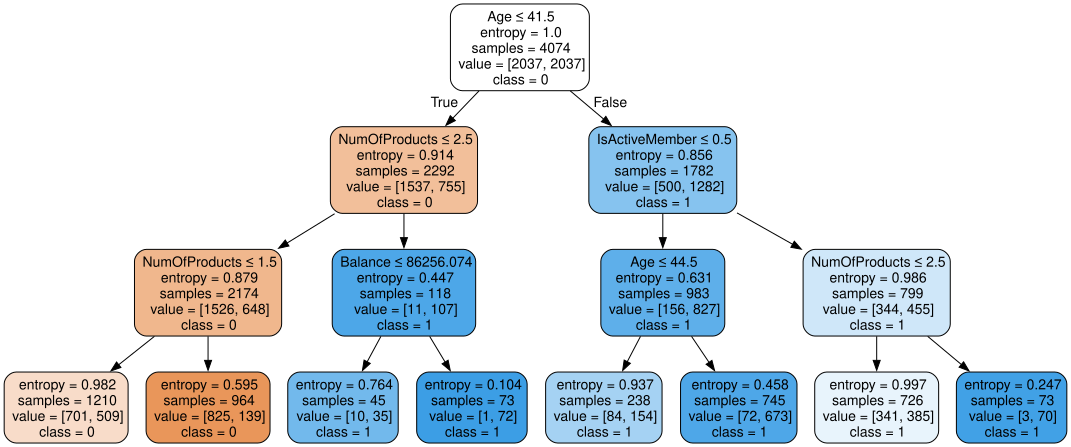

Intepretation of the Decision Tree Graph: We achieved an overall accuracy score of 71.3%. The 'Age' feature was the most important feature in the 
    decision tree model. The mean age was 41.5 (42 round up), and leaving the subscription depended on whether the person was above or below that age. Then, 
    the ‘NumberOfProducts’ feature showed that those with greater or equal to 2 products are more likely to stay while older customers who aren’t active are 
    more likely to leave a subscription. 


In [57]:
display(HTML("<h3><strong>Overall Correlation Graph for all the Features</strong></h3>"))
coorelation = pandas.get_dummies(data, drop_first=True).corr()
plt.figure(figsize=(10, 8))
seaborn.heatmap(coorelation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

print('''Intepretation of the correlation matrix: The closer the number of a feature row with the feature column to either a 1 or -1, the 
    more correlated they are. The closer the value is to 1, the more the correlation they have in a positive direction and the closer to -1,
    the more correlated they are in a negative direction. A value of 0 means no correlation. For example, 'CreditScore' shows no correlation 
    to 'Gender' as it has a value of 0.00. On the other hand, 'Age' and 'Exited' have a correlation of 0.29 which means they are positively 
    correlated which makes sense since older age is more likely to leave a subscription since they watch fewer shows, etc., than the younger 
    generation. On the other hand, 'Balance' and 'NumOfProducts' have a correlation of -0.30 which means they are negatively correlated which 
    also makes sense since the more products you have, the less balance you have in your account.''')

display(HTML("<h3><strong>Graph for Naive Baynes Classification</strong></h3>"))

ConfusionMatrixDisplay.from_predictions(
    test_y,                    
    y_pred_naive_bayes,        
    cmap="Blues"               
)
plt.title("Naïve Bayes - confusion matrix")
plt.tight_layout()
plt.show()

print('''Intepretation of the Naive Baynes Graph: The model was able to predict 387 'True Negatives' and 302 'True Positives' correctly. It predicted 
    150 'False Positives' and 161 'False Negatives'. The overall accuracy of the model was 68.9%, which is certainly not too bad. This is a normal 
    test ratio since it depicted that our model was not biased towards one class, i.e., either 0 or 1. Furthermore, this low percentage also may indicate 
    that some data may be mis-classified, about 30%.''')

display(HTML("<h3><strong>Graph for KNN Classification</strong></h3>"))

# Plotting for odd neighbors
plt.figure(figsize=(10, 5))
plt.plot(odd_neighbors, odd_test_accuracy, 'bv--', odd_neighbors, odd_training_accuracy, 'ro--')
plt.title('KNN Classifier Accuracy With Odd Numbers')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.legend(['Test Accuracy', 'Training Accuracy'])
plt.show()

print('''Intepretation of the KNN Graph: The graph shows the different accuracy levels for different values of k. The highest accuracy is seen at 
    when k = 2 for even cases. With odd cases, k = 3 was the best. At k = 1, the model was memorizing the data because it had not seen the data 
    yet and there was very low bias with high variance. At k = 21, the model was underfitting the data because it had seen all the data and therefore, 
    there was a lot of bias. Between k = 5 and 9, we still had high accuracy, but the performance had dropped. Our test accuracy was very well able to 
    predict the data with a 76.41 percent accuracy which was very good.
    ''')

display(HTML("<h3><strong>Graph for Logistic Regression Classification</strong></h3>"))
plt.plot(c_parama_logistic, logistic_test_accuracy,'bv--', c_parama_logistic, logistic_training_accuracy,'ro--')
plt.legend(['Test Accuracy','Train Accuracy'])
plt.xlabel('C')
plt.xscale('log')
plt.title('Logistic Regression Classifier Accuracy With C Parameter')
plt.ylabel('Accuracy')
plt.show()

print('''Intepretation of the Logistic Graph: The highest accuracy score which we had obtained was 69.73%. We could see that with all the different values of 
    C-parameter tested, the best one was when c = 0.01. It gave a predicted highest value of 69.73 percent accuracy. This meant there was a very strong 
    regularization. The model dipped around the highest point but stabilized with the higher values of C. There was moderate regularization with C-parameters 
    of 0.5-1.5 and weak above values of 3. This showcased that the higher the value of the C-parameter, the weaker the regularization strength and vice versa.''')

display(HTML("<h3><strong>Graph for the SVM Classification</strong></h3>"))
plt.plot(c_parameter, svl_test_accuracy,'ro--', c_parameter, svl_training_accuracy,'bv--')
plt.legend(['Test Accuracy','Train Accuracy'])
plt.title('SVM Classifier Accuracy With C Parameter')
plt.xlabel('C')
plt.xscale('log')
plt.ylabel('Accuracy')
plt.show()

print('''Intepretation of the SVM Graph: The model was stable and accurate for its predicted values with C-parameters below 0.3 with an accuracy of 65.89 percent
    with a C-value of 0.01. At C-parameter of 15, the model underfits the data having learned all the data values. This may be due to us not properly scaling our
    data. There was then a sharp decrease in accuracy which may have been due to under fitting as the model had now seen almost all the data values. When 
    the C-parameter went above 10, the model's accuracy started to shoot back up again until it became stable throughout. The takeaway was for us was 
    to have a smaller value for C-parameter to get a stable accuracy.''')

display(HTML("<h3><strong>Graph for the Decision Tree Classification</strong></h3>"))
tree_data = tree.export_graphviz(decisionTree, out_file=None,
                                feature_names=x.columns,
                                class_names=['0', '1'],
                                filled=True, rounded=True,
                                special_characters=True)
graph = graphviz.Source(tree_data)
display(graph)

print('''Intepretation of the Decision Tree Graph: We achieved an overall accuracy score of 71.3%. The 'Age' feature was the most important feature in the 
    decision tree model. The mean age was 41.5 (42 round up), and leaving the subscription depended on whether the person was above or below that age. Then, 
    the ‘NumberOfProducts’ feature showed that those with greater or equal to 2 products are more likely to stay while older customers who aren’t active are 
    more likely to leave a subscription. ''')